<a href="https://colab.research.google.com/github/ojaspaul123/ML-Experiments/blob/main/Intermmediate/Function_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

In [3]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('titanic_file.csv')
df.head()

Saving titanic_file.csv to titanic_file.csv


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
df1 = pd.read_csv('titanic_file.csv',usecols = ['Age','Fare','Survived'])
df1

,Survived,Age,Fare
0,0,34.5,7.8292
1,1,47.0,7.0000
2,0,62.0,9.6875
3,0,27.0,8.6625
4,1,22.0,12.2875
...,...,...,...
413,0,NaN,8.0500
414,1,39.0,108.9000
415,0,38.5,7.2500
416,0,NaN,8.0500


In [5]:
df1.isnull().sum()

,0
Survived,0
Age,86
Fare,1


In [6]:
df1['Age'].fillna(df1['Age'].mean(), inplace=True)
df1['Fare'].fillna(df1['Fare'].mean(), inplace=True)

/tmp/ipykernel_17394/3076764914.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['Age'].fillna(df1['Age'].mean(), inplace=True)
/tmp/ipykernel_17394/3076764914.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

In [7]:
X = df1.iloc[:,1:3]
y = df.iloc[:,0]


In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

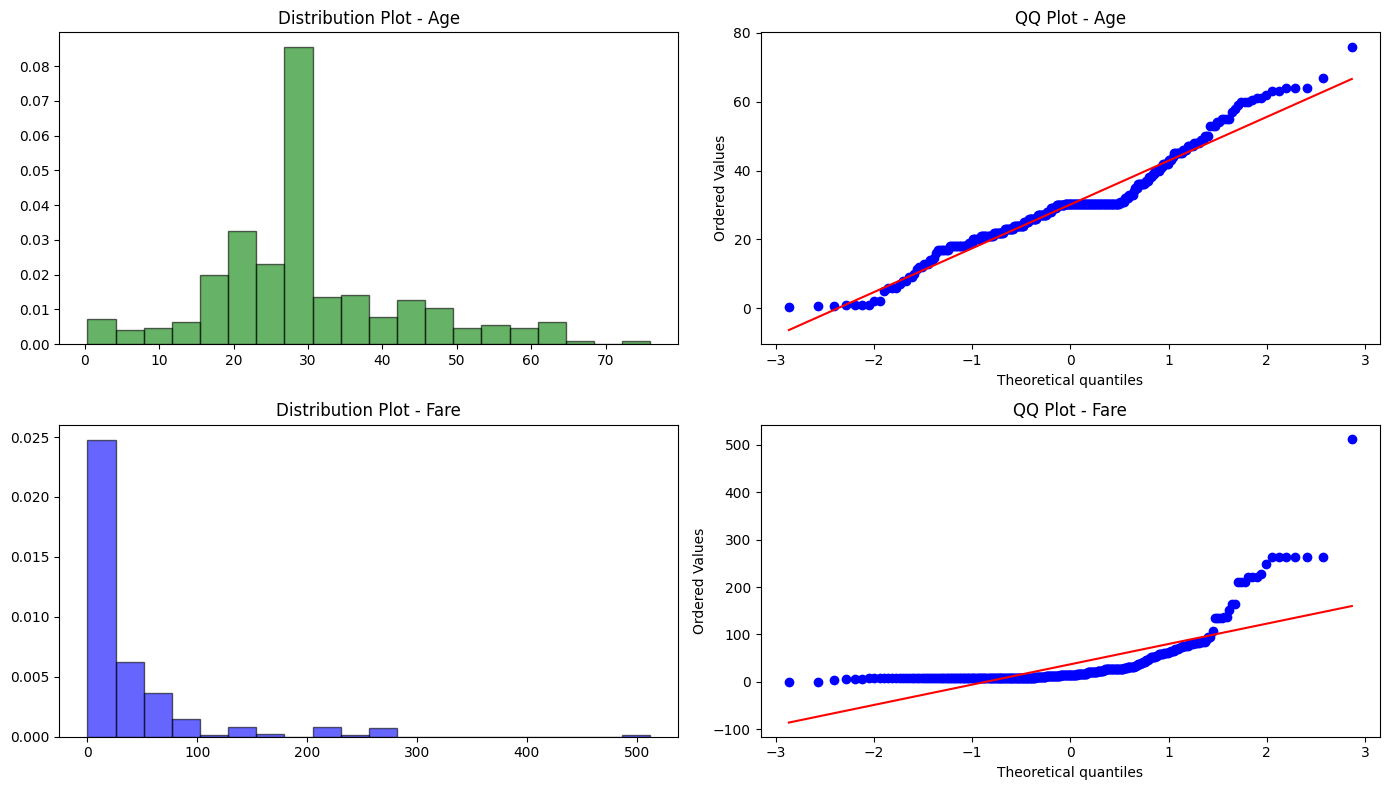

In [9]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplots with 2 rows and 2 columns
fig, axs = plt.subplots(2, 2, figsize=(14, 8))

# Plot the first distribution plot for Age
axs[0, 0].hist(X_train['Age'], bins=20, density=True, alpha=0.6, color='g', edgecolor='black')
axs[0, 0].set_title('Distribution Plot - Age')

# Plot the first QQ plot for Age
stats.probplot(X_train['Age'], dist='norm', plot=axs[0, 1])
axs[0, 1].set_title('QQ Plot - Age')

# Plot the second distribution plot for Fare
axs[1, 0].hist(X_train['Fare'], bins=20, density=True, alpha=0.6, color='b', edgecolor='black')
axs[1, 0].set_title('Distribution Plot - Fare')

# Plot the second QQ plot for Fare
stats.probplot(X_train['Fare'], dist='norm', plot=axs[1, 1])
axs[1, 1].set_title('QQ Plot - Fare')

plt.tight_layout()  # Adjust layout to prevent overlapping
plt.show()

In [10]:
%%markdown
---
Training models

---
Training models


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
lg = LogisticRegression()
dt = DecisionTreeClassifier()
lg.fit(X_train,y_train)
dt.fit(X_train,y_train)
pred_lg = lg.predict(X_test)
pred_dt = dt.predict(X_test)
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,pred_lg))
print(accuracy_score(y_test,pred_dt))

0.0
0.0


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [17]:
from sklearn.preprocessing import FunctionTransformer


trf = FunctionTransformer(func=np.log1p)
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)



In [19]:


lg.fit(X_train_transformed,y_train)
dt.fit(X_train_transformed,y_train)
y_pred = lg.predict(X_test_transformed)
y_pred1 = dt.predict(X_test_transformed)

print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))



Accuracy LR 0.0
Accuracy DT 0.0


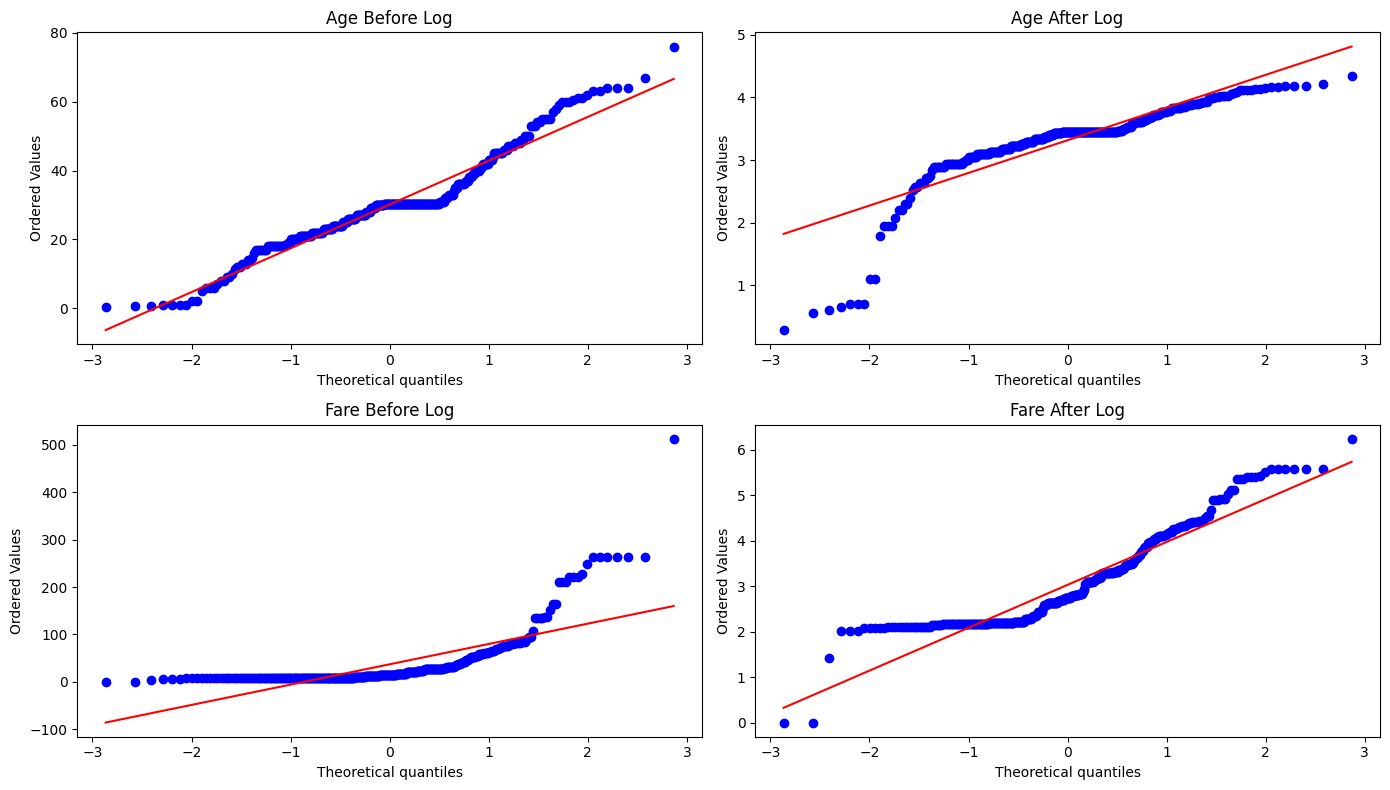

In [21]:

import matplotlib.pyplot as plt
import scipy.stats as stats

# Create subplots with 2 rows and 2 columns
fig, axs = plt.subplots(2, 2, figsize=(14, 8))

# Plot the first QQ plot for Age Before Log
stats.probplot(X_train['Age'], dist="norm", plot=axs[0, 0])
axs[0, 0].set_title('Age Before Log')

# Plot the second QQ plot for Age After Log
stats.probplot(X_train_transformed['Age'], dist="norm", plot=axs[0, 1])
axs[0, 1].set_title('Age After Log')

# Plot the third QQ plot for Fare Before Log
stats.probplot(X_train['Fare'], dist="norm", plot=axs[1, 0])
axs[1, 0].set_title('Fare Before Log')

# Plot the fourth QQ plot for Fare After Log
stats.probplot(X_train_transformed['Fare'], dist="norm", plot=axs[1, 1])
axs[1, 1].set_title('Fare After Log')

plt.tight_layout()  # Adjust layout to prevent overlapping
plt.show()



In [22]:
%%markdown
---
Reciprocal Transformer

---
Reciprocal Transformer


In [23]:


# Define the reciprocal transformation function
def reciprocal_transform(X):
    # Add a small constant value to avoid zero division
    X = X + 1e-6  # You can adjust the constant value as needed
    return 1 / X

# Create the FunctionTransformer
trf = FunctionTransformer(func=reciprocal_transform)

# Apply the transformation to the training and test data
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

# Now you can proceed with fitting your classifiers
clf.fit(X_train_transformed, y_train)
clf2.fit(X_train_transformed, y_train)
y_pred = clf.predict(X_test_transformed)
y_pred1 = clf2.predict(X_test_transformed)

# Print the accuracies
print("Accuracy LR:", accuracy_score(y_test, y_pred))
print("Accuracy DT:", accuracy_score(y_test, y_pred1))



Accuracy LR: 0.0
Accuracy DT: 0.0


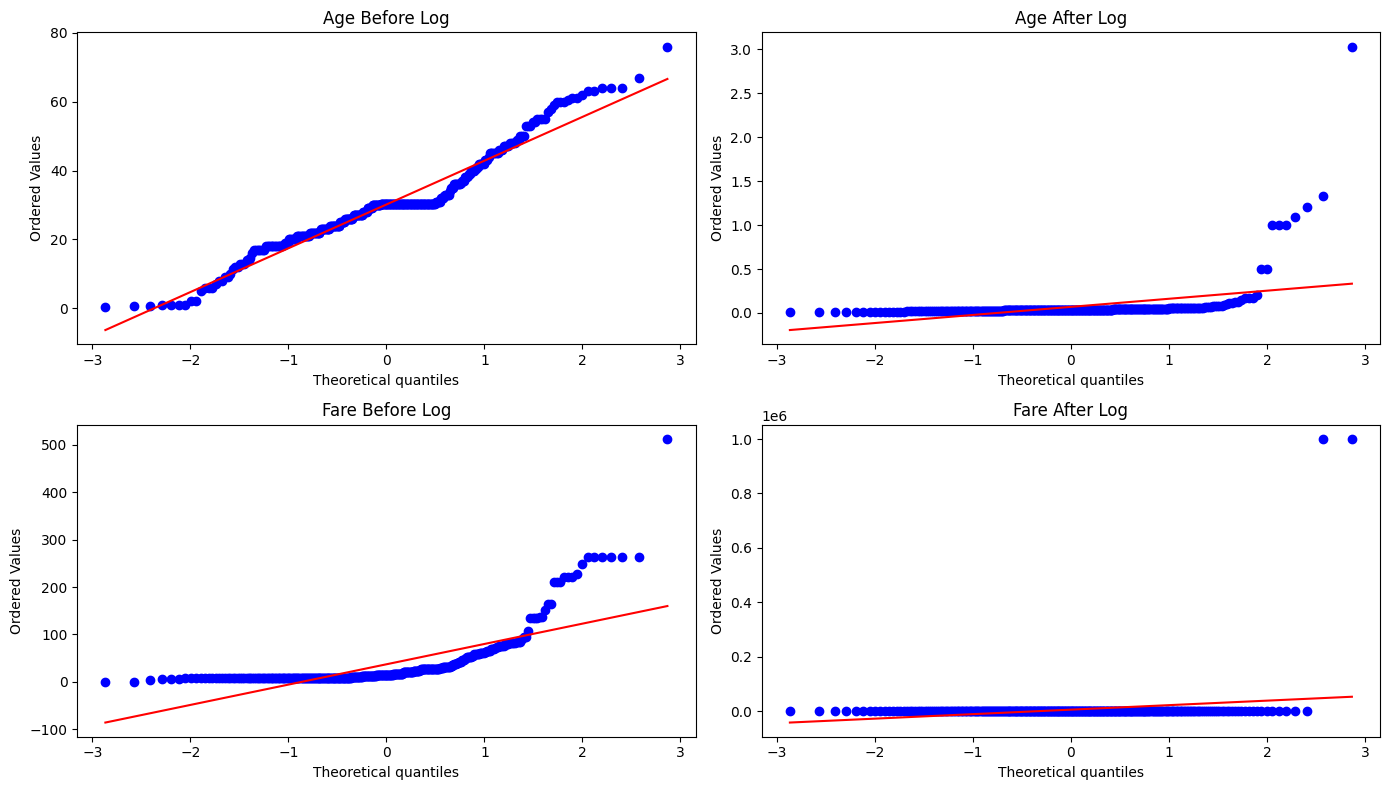

In [25]:

import matplotlib.pyplot as plt
import scipy.stats as stats

# Create subplots with 2 rows and 2 columns
fig, axs = plt.subplots(2, 2, figsize=(14, 8))

# Plot the first QQ plot for Age Before Log
stats.probplot(X_train['Age'], dist="norm", plot=axs[0, 0])
axs[0, 0].set_title('Age Before Log')

# Plot the second QQ plot for Age After Log
stats.probplot(X_train_transformed['Age'], dist="norm", plot=axs[0, 1])
axs[0, 1].set_title('Age After Log')

# Plot the third QQ plot for Fare Before Log
stats.probplot(X_train['Fare'], dist="norm", plot=axs[1, 0])
axs[1, 0].set_title('Fare Before Log')

# Plot the fourth QQ plot for Fare After Log
stats.probplot(X_train_transformed['Fare'], dist="norm", plot=axs[1, 1])
axs[1, 1].set_title('Fare After Log')

plt.tight_layout()  # Adjust layout to prevent overlapping
plt.show()



In [26]:
%%markdown
---
Square Root Transformer

---
Square Root Transformer


In [27]:
# Define the square root transformation function
def square_root_transform(X):
    return np.sqrt(X)

# Create the FunctionTransformer
trf_square_root = FunctionTransformer(func=square_root_transform)

# Apply the transformation to the 'Fare' feature in the training and test data
X_train_transformed_fare = X_train['Fare'].values.reshape(-1, 1)  # Reshape to ensure 2D array
X_test_transformed_fare = X_test['Fare'].values.reshape(-1, 1)    # Reshape to ensure 2D array
X_train_transformed_fare = trf_square_root.fit_transform(X_train_transformed_fare)
X_test_transformed_fare = trf_square_root.transform(X_test_transformed_fare)

# Now you can proceed with fitting your classifiers using the transformed 'Fare' feature
clf.fit(X_train_transformed_fare, y_train)
clf2.fit(X_train_transformed_fare, y_train)

# Predictions
y_pred = clf.predict(X_test_transformed_fare)
y_pred2 = clf2.predict(X_test_transformed_fare)

# Assess the accuracy
print("Accuracy LR:", accuracy_score(y_test, y_pred))
print("Accuracy DT:", accuracy_score(y_test, y_pred2))

Accuracy LR: 0.0
Accuracy DT: 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


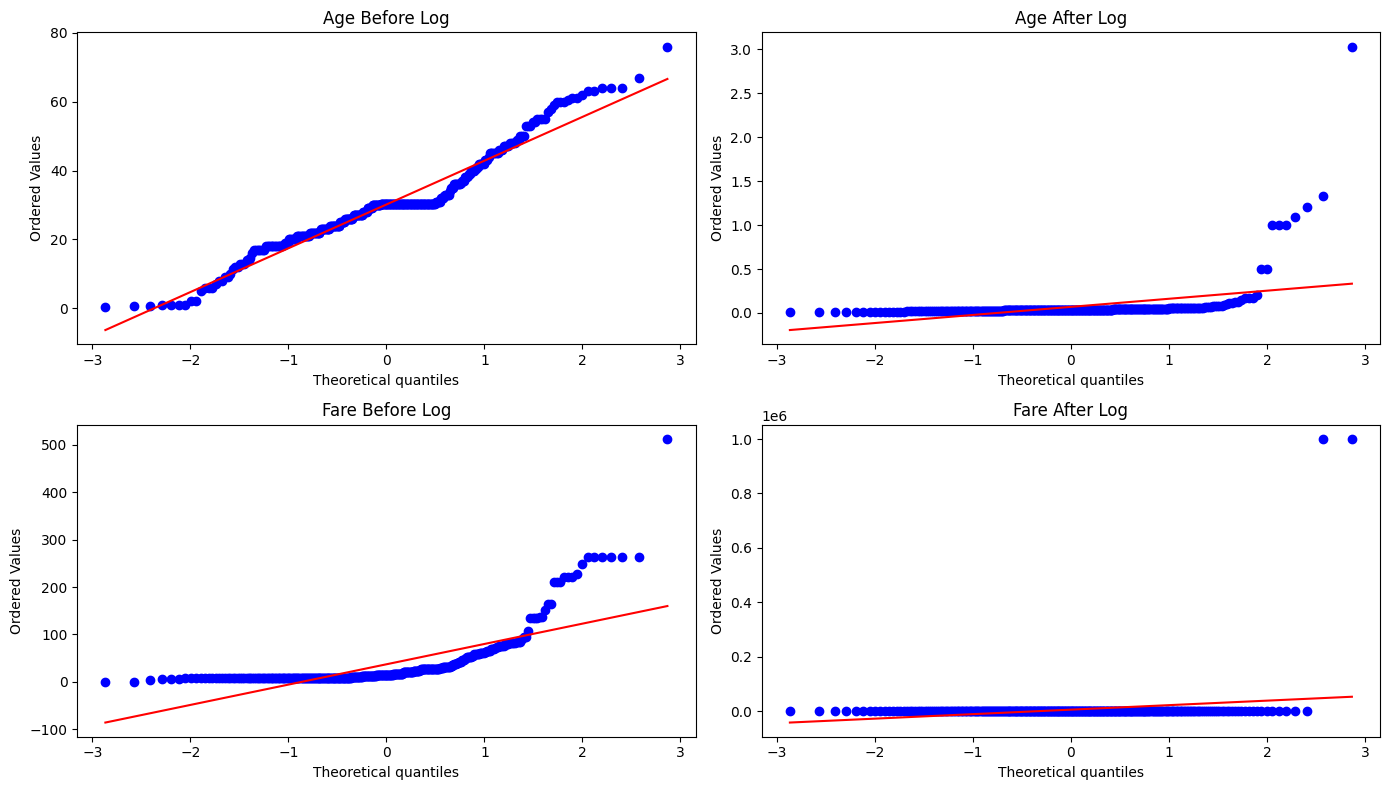

In [28]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Create subplots with 2 rows and 2 columns
fig, axs = plt.subplots(2, 2, figsize=(14, 8))

# Plot the first QQ plot for Age Before Log
stats.probplot(X_train['Age'], dist="norm", plot=axs[0, 0])
axs[0, 0].set_title('Age Before Log')

# Plot the second QQ plot for Age After Log
stats.probplot(X_train_transformed['Age'], dist="norm", plot=axs[0, 1])
axs[0, 1].set_title('Age After Log')

# Plot the third QQ plot for Fare Before Log
stats.probplot(X_train['Fare'], dist="norm", plot=axs[1, 0])
axs[1, 0].set_title('Fare Before Log')

# Plot the fourth QQ plot for Fare After Log
stats.probplot(X_train_transformed['Fare'], dist="norm", plot=axs[1, 1])
axs[1, 1].set_title('Fare After Log')

plt.tight_layout()  # Adjust layout to prevent overlapping
plt.show()

In [29]:
%%markdown
---
Disclaimer

---
Disclaimer


In [35]:
%%markdown
**Here, all the forms of transformers gives same accuracy score but each transformer accuracy score is slightly different from each other.**

**Here, all the forms of transformers gives same accuracy score but each transformer accuracy score is slightly different from each other.**
